# 🇹🇭 Thai Fake News Detection — Fine-tuning with Unsloth + Qwen2.5

**Task:** Binary text classification — ข่าวจริง / ข่าวปลอม  
**Dataset:** [EXt1/Thai-True-Fake-News](https://huggingface.co/datasets/EXt1/Thai-True-Fake-News)  
**Model:** Qwen2.5-1.5B-Instruct (4-bit quantized) via Unsloth
**Framework:** Unsloth + TRL SFTTrainer  

---
### 📌 Notebook Structure
1. Install dependencies  
2. Load & explore dataset  
3. Pre-process & split data  
4. Load model with Unsloth  
5. Format data with prompt template  
6. Fine-tune with LoRA (SFTTrainer)  
7. Evaluate on test set (Accuracy, F1, Confusion Matrix)  
8. Interactive demo (Gradio)  



In [ ]:
# ติดตั้ง Library ที่จำเป็น
!pip install unsloth datasets scikit-learn gradio matplotlib seaborn --quiet
!pip install trl transformers accelerate bitsandbytes --quiet

In [ ]:
from unsloth import FastLanguageModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from transformers import TrainingArguments
from trl import SFTTrainer
import torch
import warnings, re
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")
print(f"🖥️  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"🔢  CUDA available: {torch.cuda.is_available()}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ All libraries imported successfully!
🖥️  GPU: Tesla T4
🔢  CUDA available: True


## 📂 Step 1 — Load & Explore Dataset

**Dataset:** `EXt1/Thai-True-Fake-News`  
- **Unnamed: 0** — Row ID  
- **Title** — Thai news headline (input)  
- **Verification_Status** — `ข่าวจริง` (real) or `ข่าวปลอม` (fake) (label)


In [ ]:
# โหลด Dataset จาก Hugging Face
dataset = load_dataset("EXt1/Thai-True-Fake-News")
df = dataset["train"].to_pandas()

print(f"📊 Dataset Shape: {df.shape}")
print(f"\n🏷️  Columns: {df.columns.tolist()}")
print(f"\n📋 Sample rows:")
df.head(10)

📊 Dataset Shape: (6004, 3)

🏷️  Columns: ['Unnamed: 0', 'Title', 'Verification_Status']

📋 Sample rows:


,Unnamed: 0,Title,Verification_Status
0,3413.0,กรมพัฒนาธุรกิจการค้าอนุญาตใบทะเบียนพาณิชย์ราย...,ข่าวปลอม
1,7926.0,กรมการจัดหางานส่งเสริมให้ชาวไทยมีรายได้ เฉลี่...,ข่าวปลอม
2,3285.0,ตลาดหลักทรัพย์แห่งประเทศไทยเปิดลงทุนเพื่อหาค่...,ข่าวปลอม
3,1972.0,ตลาดหลักทรัพย์ฯ เปิดพอร์ตหุ้นธนาคารกำไรสูง 48...,ข่าวปลอม
4,7318.0,ผู้บริหารธ. ออมสินไลน์เชิญชวนกู้เงินหลักหมื่น...,ข่าวปลอม
5,3733.0,เพิ่มเบี้ยผู้สูงอายุ คนละ 100 บาท ให้ทุกคนไป...,ข่าวปลอม
6,2912.0,เล่นมือถือในที่มืดนาน ทำให้เป็นมะเร็งตาหรือตา...,ข่าวปลอม
7,1249.0,กรุงไทยเปิดเว็บไซต์ https://88886666z.top/ ปล...,ข่าวปลอม
8,7301.0,"รัฐบาลแจกเงินคนละ 1,000 – 5,000 บาท สามารถกดเ...",ข่าวปลอม
9,6731.0,กลุ่มเฟซบุ๊กชื่อ ‘ไทยรู้สู้โควิด’ เป็นกลุ่มขอ...,ข่าวปลอม


📊 Label Distribution
Verification_Status
ข่าวปลอม    3002
ข่าวจริง    3002
Name: count, dtype: int64

🔵 ข่าวจริง (Real) : 3,002
🔴 ข่าวปลอม (Fake) : 3,002


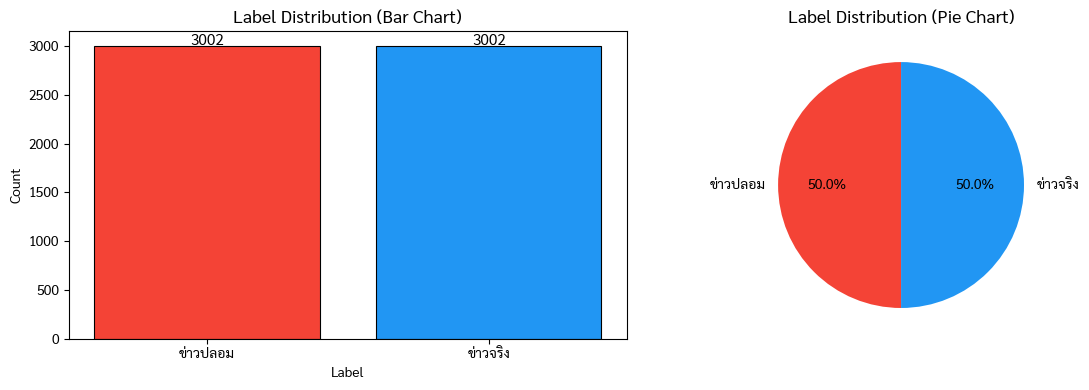


✅ Distribution plot saved!


In [ ]:
# ตรวจสอบ Label Distribution
import matplotlib.font_manager as fm

!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf -O Sarabun-Regular.ttf
fm.fontManager.addfont("Sarabun-Regular.ttf")
plt.rcParams["font.family"] = "Sarabun"

print("=" * 50)
print("📊 Label Distribution")
print("=" * 50)
label_counts = df["Verification_Status"].value_counts()
print(label_counts)
print(f"\n🔵 ข่าวจริง (Real) : {label_counts.get('ข่าวจริง', 0):,}")
print(f"🔴 ข่าวปลอม (Fake) : {label_counts.get('ข่าวปลอม', 0):,}")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values,
            color=["#F44336","#2196F3"], edgecolor="black", linewidth=0.8)
axes[0].set_title("Label Distribution (Bar Chart)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=11, fontweight="bold")

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct="%1.1f%%", colors=[ "#F44336","#2196F3"], startangle=90)
axes[1].set_title("Label Distribution (Pie Chart)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n✅ Distribution plot saved!")

## 🔧 Step 2 — Pre-process & Split Data

Split ratio: **70% train / 15% validation / 15% test**  
Stratified split ensures equal label balance across all sets.


In [ ]:
# ทำความสะอาดข้อมูล
df = df.dropna(subset=["Title", "Verification_Status"]).reset_index(drop=True)
df["Title"] = df["Title"].astype(str).str.strip()

# กรองเฉพาะ label ที่ถูกต้อง
valid_labels = ["ข่าวจริง", "ข่าวปลอม"]
df = df[df["Verification_Status"].isin(valid_labels)].reset_index(drop=True)

print(f"✅ Clean dataset: {len(df):,} rows")

# แบ่ง train / val / test  (70 / 15 / 15)
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["Verification_Status"])
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["Verification_Status"])

print(f"\n📦 Split sizes:")
print(f"  🔹 Train : {len(train_df):,} rows")
print(f"  🔹 Val   : {len(val_df):,} rows")
print(f"  🔹 Test  : {len(test_df):,} rows")

# Verify label balance
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = d["Verification_Status"].value_counts()
    print(f"\n  {name}: ข่าวจริง={counts.get('ข่าวจริง',0)}, ข่าวปลอม={counts.get('ข่าวปลอม',0)}")

✅ Clean dataset: 6,004 rows

📦 Split sizes:
  🔹 Train : 4,202 rows
  🔹 Val   : 901 rows
  🔹 Test  : 901 rows

  Train: ข่าวจริง=2101, ข่าวปลอม=2101

  Val: ข่าวจริง=450, ข่าวปลอม=451

  Test: ข่าวจริง=451, ข่าวปลอม=450


## 🤖 Step 3 — Load Qwen2.5-1.5B with Unsloth

- **Model:** `unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit`  
- **4-bit Quantization (QLoRA):** ลดขนาด VRAM จาก ~28GB → ~6GB  
- **LoRA rank = 16:** Fine-tune เฉพาะ adapter layers แทนทั้ง model  


In [ ]:
# กำหนด config
max_seq_length = 512   # ความยาว token สูงสุด (ข่าวสั้น → 512 พอ)
dtype = None           # Auto-detect
load_in_4bit = True    # QLoRA - ประหยัด VRAM

# โหลด Model + Tokenizer ด้วย Unsloth
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
)

print("✅ Model loaded successfully!")
print(f"📐 Model type: {type(model).__name__}")

==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Model loaded successfully!
📐 Model type: Qwen2ForCausalLM


In [ ]:
# เพิ่ม LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,      # LoRA rank (ยิ่งสูง = เรียนรู้มากขึ้น แต่ใช้ VRAM มากขึ้น)
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha     = 16,
    lora_dropout   = 0.05,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",  # ประหยัด VRAM เพิ่มเติม
    random_state   = 42,
)

# นับจำนวน parameter
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Model Parameters:")
print(f"  Total     : {total_params:,}")
print(f"  Trainable : {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print(f"\n✅ LoRA adapters added!")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.3.3 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.



📊 Model Parameters:
  Total     : 907,081,216
  Trainable : 18,464,768 (2.04%)

✅ LoRA adapters added!


## 📝 Step 4 — Prompt Template (Alpaca Format)

ใช้ **Alpaca-style prompt** เพื่อบอกให้ model รู้ว่า:
- Task คืออะไร (instruction)
- Input คืออะไร (title ข่าว)
- Output ที่ต้องการ (ข่าวจริง / ข่าวปลอม)


In [ ]:
# Alpaca-style prompt template สำหรับ Fake News Detection
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
คุณเป็น AI ผู้เชี่ยวชาญด้านการตรวจสอบข่าวภาษาไทย กรุณาวิเคราะห์หัวข้อข่าวต่อไปนี้และตอบว่าเป็น "ข่าวจริง" หรือ "ข่าวปลอม" เท่านั้น

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token  # ต้องใส่ EOS ท้าย

def format_prompt(title, label=""):
    """แปลง row เป็น prompt string"""
    return alpaca_prompt.format(title, label) + (EOS_TOKEN if label else "")

# แสดงตัวอย่าง prompt
example_row = train_df.iloc[0]
print("📄 Example Prompt:\n")
print(format_prompt(example_row["Title"], example_row["Verification_Status"]))

📄 Example Prompt:

Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
คุณเป็น AI ผู้เชี่ยวชาญด้านการตรวจสอบข่าวภาษาไทย กรุณาวิเคราะห์หัวข้อข่าวต่อไปนี้และตอบว่าเป็น "ข่าวจริง" หรือ "ข่าวปลอม" เท่านั้น

### Input:
ก.ล.ต. ชวนลงทุนหุ้นทองคำให้ผลตอบแทนสูง เปิดพอร์ตเริ่มต้น 1,000 บาท

### Response:
ข่าวปลอม<|im_end|>


In [ ]:
# แปลง DataFrame เป็น Hugging Face Dataset format
from datasets import Dataset

def prepare_dataset(dataframe):
    """แปลง DataFrame → HF Dataset ที่พร้อม train"""
    texts = []
    for _, row in dataframe.iterrows():
        text = format_prompt(row["Title"], row["Verification_Status"])
        texts.append({"text": text})
    return Dataset.from_list(texts)

train_dataset = prepare_dataset(train_df)
val_dataset   = prepare_dataset(val_df)

print(f"✅ Train dataset: {len(train_dataset):,} samples")
print(f"✅ Val   dataset: {len(val_dataset):,} samples")
print(f"\n🔍 Sample entry:")
print(train_dataset[0]["text"][:300])

✅ Train dataset: 4,202 samples
✅ Val   dataset: 901 samples

🔍 Sample entry:
Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
คุณเป็น AI ผู้เชี่ยวชาญด้านการตรวจสอบข่าวภาษาไทย กรุณาวิเคราะห์หัวข้อข่าวต่อไปนี้และตอบว่าเป็น "ข่าวจริง" หรือ "ข่าวปลอม" เท


## 🏋️ Step 5 — Fine-tune with SFTTrainer

**Hyperparameters:**
| Parameter | Value |
|---|---|
| Epochs | 3 |
| Batch size | 2 |
| Gradient accumulation | 4 (effective batch = 8) |
| Learning rate | 2e-4 |
| LR Scheduler | cosine |
| Optimizer | adamw_8bit |


In [ ]:
# กำหนด Training Arguments
training_args = TrainingArguments(
    output_dir              = "./qwen_fakenews_output",
    num_train_epochs        = 3,
    per_device_train_batch_size  = 2,
    per_device_eval_batch_size   = 2,
    gradient_accumulation_steps  = 4,
    warmup_steps            = 0.05,
    learning_rate           = 2e-4,
    lr_scheduler_type       = "cosine",
    optim                   = "adamw_8bit",
    fp16                    = not torch.cuda.is_bf16_supported(),
    bf16                    = torch.cuda.is_bf16_supported(),
    logging_steps           = 10,
    eval_strategy           = "epoch",   # ← changed from evaluation_strategy
    save_strategy           = "epoch",
    load_best_model_at_end  = True,
    metric_for_best_model   = "eval_loss",
    seed                    = 42,
    report_to               = "none",
)

# สร้าง SFTTrainer
trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = train_dataset,
    eval_dataset       = val_dataset,
    dataset_text_field = "text",
    max_seq_length     = max_seq_length,
    dataset_num_proc   = 2,
    args               = training_args,
)

print("✅ Trainer created!")
print(f"📌 Training on {len(train_dataset):,} samples")
print(f"📌 Validating on {len(val_dataset):,} samples")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4202 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/901 [00:00<?, ? examples/s]

✅ Trainer created!
📌 Training on 4,202 samples
📌 Validating on 901 samples


In [ ]:
# 🚀 เริ่ม Training!
print("Starting Fine-tuning...\n")
trainer_stats = trainer.train()

print("\n✅ Training Complete!")
print(f"⏱️  Total training time: {trainer_stats.metrics['train_runtime']:.1f} seconds")
print(f"📉 Final train loss   : {trainer_stats.metrics['train_loss']:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Starting Fine-tuning...



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,202 | Num Epochs = 3 | Total steps = 1,578
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Epoch,Training Loss,Validation Loss
1,0.485333,0.497279
2,0.428270,0.478834
3,0.348738,0.488464


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_co


✅ Training Complete!
⏱️  Total training time: 3006.8 seconds
📉 Final train loss   : 0.4534


## 📊 Step 6 — Evaluate on Test Set

Metrics: **Accuracy**, **F1 Score** (weighted), **Classification Report**, **Confusion Matrix**


In [ ]:
# ฟังก์ชัน inference
FastLanguageModel.for_inference(model)  # เปิด optimized inference mode

def predict_label(title: str) -> str:
    """รับหัวข้อข่าว → คืนค่า 'ข่าวจริง' หรือ 'ข่าวปลอม'"""
    prompt = alpaca_prompt.format(title, "")   # ไม่ใส่ label (ให้ model ทาย)
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = 10,
            temperature    = 0.1,
            do_sample      = True,
            pad_token_id   = tokenizer.eos_token_id,
        )

    # Decode เฉพาะ token ที่ generate ใหม่
    generated = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()

    # Map output → clean label
    if "จริง" in generated:
        return "ข่าวจริง"
    elif "ปลอม" in generated:
        return "ข่าวปลอม"
    else:
        return generated   # return raw ถ้า model ตอบผิดรูปแบบ

# ทดสอบกับตัวอย่าง
sample_title = test_df.iloc[0]["Title"]
sample_label = test_df.iloc[0]["Verification_Status"]
pred = predict_label(sample_title)
print(f"📰 Title  : {sample_title}")
print(f"🏷️  True   : {sample_label}")
print(f"🤖 Predict: {pred}")

📰 Title  : ออมสินปล่อยสินเชื่อ Softloan ให้ยืม 5,000 – 500,000 บาท ดอกเบี้ยต่ำ ไม่ต้องค้ำ ผ่านไลน์
🏷️  True   : ข่าวปลอม
🤖 Predict: ข่าวปลอม


In [ ]:
# ประเมินผลบน Test Set ทั้งหมด
from tqdm.auto import tqdm

print("🔄 Running inference on test set...\n")
y_true = test_df["Verification_Status"].tolist()
y_pred = []

for title in tqdm(test_df["Title"].tolist(), desc="Predicting"):
    y_pred.append(predict_label(title))

# คำนวณ metrics
accuracy = accuracy_score(y_true, y_pred)
f1       = f1_score(y_true, y_pred, average="weighted",
                    labels=["ข่าวจริง", "ข่าวปลอม"])

print(f"\n{'='*55}")
print("📊 EVALUATION RESULTS")
print(f"{'='*55}")
print(f"✅ Accuracy  : {accuracy*100:.2f}%")
print(f"✅ F1 Score  : {f1*100:.2f}%  (weighted)")
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred,
                             target_names=["ข่าวจริง", "ข่าวปลอม"],
                             zero_division=0))

🔄 Running inference on test set...



Predicting:   0%|          | 0/901 [00:00<?, ?it/s]


📊 EVALUATION RESULTS
✅ Accuracy  : 90.23%
✅ F1 Score  : 90.23%  (weighted)

📋 Classification Report:
              precision    recall  f1-score   support

    ข่าวจริง       0.89      0.92      0.90       451
    ข่าวปลอม       0.92      0.88      0.90       450

    accuracy                           0.90       901
   macro avg       0.90      0.90      0.90       901
weighted avg       0.90      0.90      0.90       901



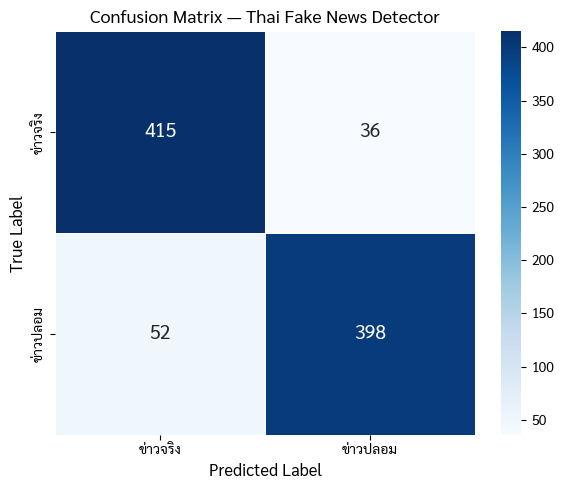

✅ Confusion matrix saved!


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=["ข่าวจริง", "ข่าวปลอม"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ข่าวจริง", "ข่าวปลอม"],
            yticklabels=["ข่าวจริง", "ข่าวปลอม"],
            linewidths=0.5, annot_kws={"size": 14})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix — Thai Fake News Detector", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved!")

In [ ]:
# แสดงตัวอย่าง Predictions 10 รายการ
print("📝 Sample Predictions:\n")
print(f"{'#':<4} {'True Label':<15} {'Predicted':<15} {'Match':<6} Title")
print("-"*90)
for i in range(min(10, len(test_df))):
    true  = y_true[i]
    pred  = y_pred[i]
    match = "✅" if true == pred else "❌"
    title = test_df.iloc[i]["Title"][:55]
    print(f"{i+1:<4} {true:<15} {pred:<15} {match:<6} {title}")

📝 Sample Predictions:

#    True Label      Predicted       Match  Title
------------------------------------------------------------------------------------------
1    ข่าวปลอม        ข่าวปลอม        ✅      ออมสินปล่อยสินเชื่อ Softloan ให้ยืม 5,000 – 500,000 บาท
2    ข่าวจริง        ข่าวจริง        ✅      ครม. ตรึงค่าน้ำมันดีเซลที่ 33 บ./ลิตร ถึง 31 ต.ค. 67
3    ข่าวปลอม        ข่าวปลอม        ✅      รับทำใบขับขี่ถูกกฎหมาย ไม่ต้องไปสอบเอง ทางเพจสอบให้
4    ข่าวปลอม        ข่าวปลอม        ✅      ออมสินปล่อยสินเชื่อผ่านเพจ Mymo สินเชื่อทั่วไทย
5    ข่าวปลอม        ข่าวปลอม        ✅      เจ้าของเวทีประกวดนางงามชื่อดังเชิญชวนลงทุนหุ้น 95 บาท ต
6    ข่าวปลอม        ข่าวปลอม        ✅      แจ้งความออนไลน์ ผ่านเพจศูนย์ป้องกันและปราบปรามการฟอกเงิ
7    ข่าวปลอม        ข่าวปลอม        ✅      ประเทศไทยอยู่ในกลุ่มเสี่ยงประเทศล้มละลาย เนื่องจากผิดนั
8    ข่าวปลอม        ข่าวปลอม        ✅      บัญชีไลน์ผู้บริหารของสำนักงาน ก.ล.ต. ชักชวนลงทุน
9    ข่าวจริง        ข่าวจริง        ✅      จีนเพิ่มโควตาใ

## 🙋 Step 7 — Student Q&A Section (5 Questions)




In [ ]:
# 🧑‍🎓 Student Questions — ทดสอบ model ด้วยคำถามของนักเรียน
student_questions = [
    # (คำถาม/หัวข้อข่าว, label ที่คาดหวัง)
    ("รัฐบาลแจกเงิน 10,000 บาทให้ทุกคนฟรีผ่าน LINE",              "ข่าวปลอม"),
    ("กทม.คุมเข้มสุ่มตรวจร้านค้าสถานบริการ ปิด/ห้ามขาย",              "ข่าวจริง"),
    ("ดื่มน้ำขิงเช้าเย็นรักษามะเร็งได้ 100% แพทย์ยืนยัน",        "ข่าวปลอม"),
    ("ธนาคารแห่งประเทศไทยขึ้นอัตราดอกเบี้ยนโยบาย 0.25%",         "ข่าวจริง"),
    ("วัคซีนโควิดทำให้ DNA เปลี่ยนและควบคุมจิตใจ",               "ข่าวปลอม"),
]

print("🧑‍🎓 Student Q&A Results")
print("="*80)
for i, (question, expected) in enumerate(student_questions, 1):
    prediction = predict_label(question)
    status     = "✅ ถูก" if prediction == expected else "❌ ผิด"
    print(f"\nQ{i}: {question}")
    print(f"   Expected  : {expected}")
    print(f"   Predicted : {prediction}  {status}")
print("\n" + "="*80)

🧑‍🎓 Student Q&A Results

Q1: รัฐบาลแจกเงิน 10,000 บาทให้ทุกคนฟรีผ่าน LINE
   Expected  : ข่าวปลอม
   Predicted : ข่าวปลอม  ✅ ถูก

Q2: กทม.คุมเข้มสุ่มตรวจร้านค้าสถานบริการ ปิด/ห้ามขาย
   Expected  : ข่าวจริง
   Predicted : ข่าวจริง  ✅ ถูก

Q3: ดื่มน้ำขิงเช้าเย็นรักษามะเร็งได้ 100% แพทย์ยืนยัน
   Expected  : ข่าวปลอม
   Predicted : ข่าวปลอม  ✅ ถูก

Q4: ธนาคารแห่งประเทศไทยขึ้นอัตราดอกเบี้ยนโยบาย 0.25%
   Expected  : ข่าวจริง
   Predicted : ข่าวจริง  ✅ ถูก

Q5: วัคซีนโควิดทำให้ DNA เปลี่ยนและควบคุมจิตใจ
   Expected  : ข่าวปลอม
   Predicted : ข่าวปลอม  ✅ ถูก



## 💾 Step 8 — Save Fine-tuned Model

In [ ]:
from huggingface_hub import login

# Login to Hugging Face
login(token="xxxxxxxxxxxxx")  # get from https://huggingface.co/settings/tokens

# Save LoRA adapter to Hugging Face Hub
model.push_to_hub("Phantatt/qwen-thai-fakenews_QWEN2.5_1.5B")
tokenizer.push_to_hub("Phantatt/qwen-thai-fakenews_QWEN2.5_1.5B")

print("✅ Model pushed to Hugging Face Hub!")
print("🔗 https://huggingface.co/Phantatt/qwen-thai-fakenews_QWEN2.5_1.5B")

README.md:   0%|          | 0.00/566 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 45.7kB / 73.9MB            

Saved model to https://huggingface.co/Phantatt/qwen-thai-fakenews_QWEN2.5_1.5B


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpzn_shylv/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

✅ Model pushed to Hugging Face Hub!
🔗 https://huggingface.co/Phantatt/qwen-thai-fakenews_QWEN2.5_1.5B


## 🎮 Step 9 — Interactive Demo with Gradio

In [ ]:
import gradio as gr

def check_news(title: str) -> str:
    if not title.strip():
        return "⚠️ กรุณาใส่หัวข้อข่าว"
    label = predict_label(title.strip())
    if label == "ข่าวจริง":
        return f"✅ {label}\n\nโมเดลประเมินว่าหัวข้อข่าวนี้มีความน่าเชื่อถือ"
    elif label == "ข่าวปลอม":
        return f"❌ {label}\n\nโมเดลประเมินว่าหัวข้อข่าวนี้มีแนวโน้มเป็นข่าวปลอม กรุณาตรวจสอบแหล่งที่มาก่อนแชร์"
    else:
        return f"❓ ไม่แน่ใจ: {label}"

demo = gr.Interface(
    fn          = check_news,
    inputs      = gr.Textbox(
                    lines       = 3,
                    placeholder = "พิมพ์หัวข้อข่าวภาษาไทยที่ต้องการตรวจสอบ...",
                    label       = "📰 หัวข้อข่าว"),
    outputs     = gr.Textbox(label="🤖 ผลการวิเคราะห์"),
    title       = "🇹🇭 Thai Fake News Detector (Fine-tuned Qwen2.5-7B)",
    description = "ใส่หัวข้อข่าวภาษาไทยเพื่อตรวจสอบว่าเป็น ข่าวจริง หรือ ข่าวปลอม",
    examples    = [
        ["รัฐบาลแจกเงิน 10,000 บาทฟรีผ่าน LINE ลงทะเบียนด่วน"],
        ["กรมอุตุฯ ประกาศเตือนฝนตกหนักภาคใต้ 48 ชั่วโมงข้างหน้า"],
        ["ดื่มน้ำมะนาวทุกเช้ารักษาโรคมะเร็งได้ หมอยืนยัน"],
    ],
    flagging_mode = "never",
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8436f0ae4fa86c6899.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
